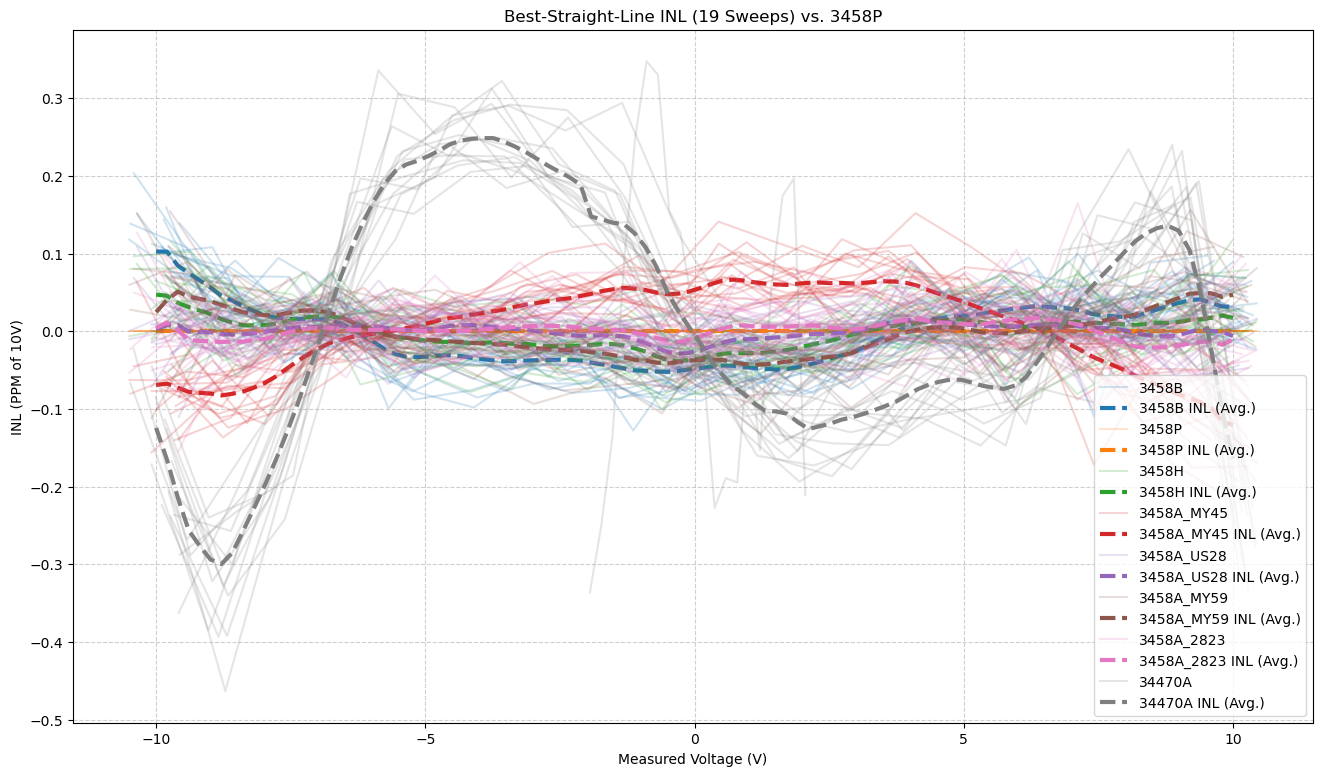

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.interpolate import interp1d

# --- Lock Colors ---
DEFAULT_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Data Ingestion ---
file_pattern = 'INL/3458A_34470A_10V_INL_*.csv'
file_list = glob.glob(file_pattern)

V_FULL_SCALE = 10.0 
PPM_FACTOR = V_FULL_SCALE / 1000000.0

V_MIN, V_MAX, N_POINTS = -10, 10, 100 
V_MASTER_AXIS = np.linspace(V_MIN, V_MAX, N_POINTS)

raw_inls_to_plot = {} 
all_interpolated_inls = {} 
meter_colors = {}

# --- Calculate INL for Each Sweep ---
color_index = 0
for file in file_list[:]:
    df_sweep = pd.read_csv(file)
    
    # Reference meter to which we compare all
    V_REF = df_sweep['3458P']
    
    # Don't plot calibrator setting and temperature sensor
    measurement_columns = df_sweep.columns[1:-1] 

    for column_name in measurement_columns:
        if column_name not in meter_colors:
            meter_colors[column_name] = DEFAULT_COLORS[color_index % len(DEFAULT_COLORS)]
            color_index += 1
            
        V_METER = df_sweep[column_name]
        
        PPM_deviation = (V_METER - V_REF) / PPM_FACTOR

        # Fit function of degree 1 aka straight line with offset
        terms = np.polyfit(V_METER, PPM_deviation, 1)
        polyfunction = np.poly1d(terms)
        
        # Find deviation from this straight line
        INL_best_fit = PPM_deviation - polyfunction(V_METER)

        # Store RAW data for transparent plotting
        if column_name not in raw_inls_to_plot:
            raw_inls_to_plot[column_name] = []
        raw_inls_to_plot[column_name].append((V_METER.values, INL_best_fit.values))
        
        # Store Interpolated data for the final average line
        f_interp = interp1d(V_METER, INL_best_fit, kind='linear', bounds_error=False, fill_value=np.nan)
        INL_interpolated = f_interp(V_MASTER_AXIS)
        
        if column_name not in all_interpolated_inls:
            all_interpolated_inls[column_name] = []
        all_interpolated_inls[column_name].append(INL_interpolated)

# --- Plot underlying data and averaged curve across all sweeps ---

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlabel('Measured Voltage (V)') 
ax.set_ylabel('INL (PPM of 10V)')
ax.set_title(f"Best-Straight-Line INL ({len(file_list)} Sweeps) vs. 3458P")
fig.patch.set_facecolor('white')

for column_name in raw_inls_to_plot.keys():
    
    color = meter_colors[column_name]
    
    # --- Underlying raw sweeps ---
    for i, (v_measured, inl_raw) in enumerate(raw_inls_to_plot[column_name]):
        # But we only need one entry in the legend
        label = column_name if i == 0 else "_nolegend_" 
        ax.plot(v_measured, inl_raw, alpha=0.2, label=label, color=color)

    # --- Final averaged curve ---
    inls = all_interpolated_inls[column_name]
    avg_INL_curve = np.nanmean(np.array(inls), axis=0)
    ax.plot(V_MASTER_AXIS, avg_INL_curve, label=f'{column_name} INL (Avg.)', 
            linewidth=3, linestyle='--', color=color)

ax.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()